## Watch History Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient
from pyspark.sql import SparkSession
from pyspark.sql.functions import count

In [2]:
# SPARK SETUP
spark = SparkSession.builder \
    .appName("Netflix Big Data Project") \
    .getOrCreate()

# LOAD DATA
df = pd.read_csv("DataSets/watch_history.csv")
movies = pd.read_csv("DataSets/movies.csv")

spark_df = spark.read.csv("DataSets/watch_history.csv", header=True, inferSchema=True)
movies_spark = spark.read.csv("DataSets/movies.csv", header=True, inferSchema=True)

df.head()

,session_id,user_id,movie_id,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,is_download,user_rating
0,session_000001,user_07271,movie_0511,2025-11-13,Tablet,63.9,34.6,completed,HD,USA,False,NaN
1,session_000002,user_00861,movie_0588,2025-02-26,Laptop,120.1,44.2,started,HD,USA,False,NaN
2,session_000003,user_05391,movie_0694,2024-12-15,Desktop,572.1,84.7,started,HD,Canada,False,1.0
3,session_000004,user_05192,movie_0234,2024-09-30,Desktop,395.3,89.9,completed,SD,USA,False,5.0
4,session_000005,user_05735,movie_0390,2024-08-04,Tablet,14.6,6.2,completed,HD,USA,False,NaN


In [3]:
df.isnull().sum()

session_id                    0
user_id                       0
movie_id                      0
watch_date                    0
device_type                   0
watch_duration_minutes    12332
progress_percentage        8514
action                        0
quality                       0
location_country              0
is_download                   0
user_rating               83903
dtype: int64

In [4]:
# DATA CLEANING
df_clean = df.copy()

# Converted watch_date to datetime format
df_clean["watch_date"] = pd.to_datetime(df_clean["watch_date"])

# Checked and removed duplicate rows
print("Duplicates before removal:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Duplicates after removal:", df_clean.duplicated().sum())

# Filled missing numerical values using median
df_clean["watch_duration_minutes"] = df_clean["watch_duration_minutes"].fillna(
    df_clean["watch_duration_minutes"].median()
)

df_clean["progress_percentage"] = df_clean["progress_percentage"].fillna(
    df_clean["progress_percentage"].median()
)

# Created indicator for missing ratings and filled missing ratings with 0
df_clean["has_user_rating"] = df_clean["user_rating"].notna()
df_clean["user_rating"] = df_clean["user_rating"].fillna(0)

df_clean.isnull().sum()

Duplicates before removal: 5000
Duplicates after removal: 0


session_id                0
user_id                   0
movie_id                  0
watch_date                0
device_type               0
watch_duration_minutes    0
progress_percentage       0
action                    0
quality                   0
location_country          0
is_download               0
user_rating               0
has_user_rating           0
dtype: int64

In [5]:
# MERGE DATASETS
df_merged = df_clean.merge(movies, on="movie_id", how="left")
df_merged[["movie_id", "title", "genre_primary"]].head()

,movie_id,title,genre_primary
0,movie_0511,Dragon Princess,Music
1,movie_0588,Queen Queen,Sci-Fi
2,movie_0694,Kingdom Day,Action
3,movie_0234,An Fire,Horror
4,movie_0390,Old Night,Fantasy


In [6]:
# SPARK TRANSFORMATION: MOST WATCHED MOVIES
top_movies_spark = spark_df.groupBy("movie_id") \
    .agg(count("*").alias("views")) \
    .orderBy("views", ascending=False)

top_movies_spark.show(10)

+----------+-----+
|  movie_id|views|
+----------+-----+
|movie_0939|  137|
|movie_0285|  137|
|movie_0852|  132|
|movie_0539|  132|
|movie_0115|  131|
|movie_0908|  131|
|movie_0590|  131|
|movie_0484|  131|
|movie_0074|  130|
|movie_0640|  130|
+----------+-----+
only showing top 10 rows


In [7]:
movies_spark = spark.read.csv("DataSets/movies.csv", header=True, inferSchema=True)

top_movies_named_spark = top_movies_spark.join(
    movies_spark,
    on="movie_id",
    how="left"
)
top_movies_named_spark.select("title", "views").show(10)

+----------------+-----+
|           title|views|
+----------------+-----+
|      Ice Secret|  113|
|Adventure Legend|   99|
|     Bright Love|   92|
|   Secret Family|  104|
|     Day Mission|  101|
|   Mission Storm|   97|
|    Little Dream|  106|
|   Family Battle|   99|
|    Night Secret|   94|
|    Dream Battle|   91|
+----------------+-----+
only showing top 10 rows


In [8]:
top_movies_pd = top_movies_named_spark.toPandas()

# VISUALIZATION

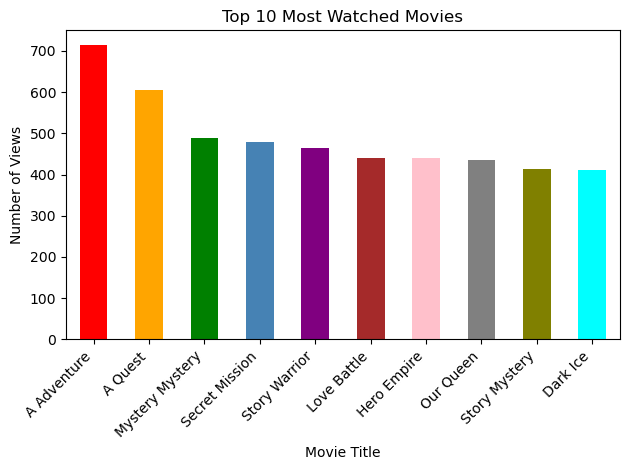

In [9]:
# TOP MOVIES
top_movies_named = df_merged["title"].value_counts().head(10)

top_movies_named.plot(
    kind='bar',
    color=[
        "red", "orange", "green", "steelblue", "purple",
        "brown", "pink", "gray", "olive", "cyan"
    ]
)

plt.title("Top 10 Most Watched Movies")
plt.xlabel("Movie Title")
plt.ylabel("Number of Views")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# ANALYSIS: MOST WATCHED GENRES

top_genres = df_merged.groupby("genre_primary").size().sort_values(ascending=False)
top_genres.head(10)

genre_primary
Adventure    7242
War          6195
Animation    6070
Action       5965
Sci-Fi       5949
Comedy       5918
Western      5551
History      5434
Romance      5423
Biography    5320
dtype: int64

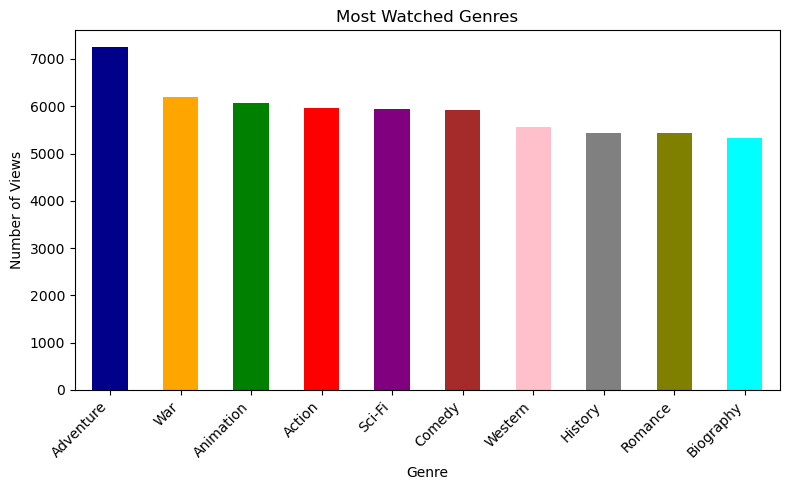

In [11]:
# VISUALIZATION 2: MOST WATCHED GENRES
plt.figure(figsize=(8, 5))
top_genres.head(10).plot(
    kind="bar",
    color=[
        "darkblue", "orange", "green", "red", "purple",
        "brown", "pink", "gray", "olive", "cyan"
    ]
)
plt.title("Most Watched Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Views")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# ANALYSIS: AVERAGE PROGRESS BY GENRE
genre_engagement = df_merged.groupby("genre_primary")["progress_percentage"].mean().sort_values(ascending=False)
genre_engagement.head(10)

genre_primary
Family       50.465578
Western      50.421456
Drama        50.414101
Action       50.361207
Comedy       50.242700
Horror       50.237372
Crime        50.235394
Biography    50.092218
Sci-Fi       50.085292
Adventure    50.076857
Name: progress_percentage, dtype: float64

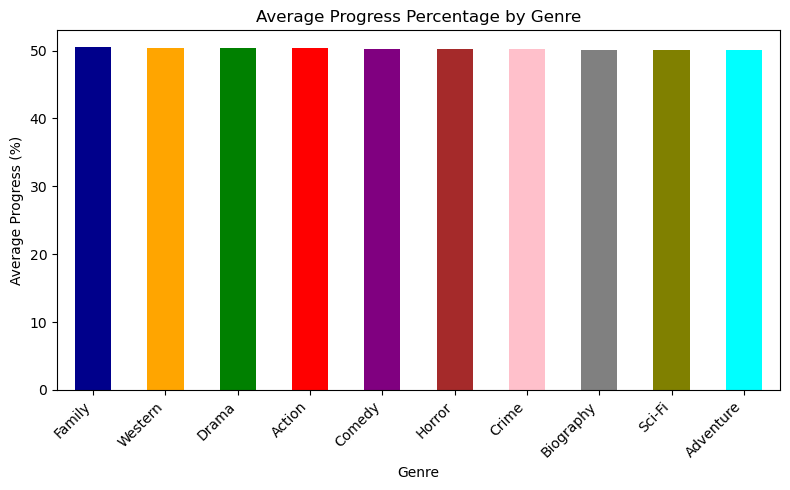

In [13]:
# VISUALIZATION 3: AVERAGE PROGRESS BY GENRE
plt.figure(figsize=(8, 5))
genre_engagement.head(10).plot(
    kind="bar",
    color=[
        "darkblue", "orange", "green", "red", "purple",
        "brown", "pink", "gray", "olive", "cyan"
    ]
)
plt.title("Average Progress Percentage by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Progress (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### MongoDB Integration

In [14]:
# PREPARE DATA FOR MONGODB
mongo_df = df_merged[
    [
        "session_id",
        "user_id",
        "movie_id",
        "title",
        "genre_primary",
        "watch_date",
        "device_type",
        "watch_duration_minutes",
        "progress_percentage",
        "action",
        "quality",
        "location_country",
        "is_download",
        "user_rating",
        "has_user_rating"
    ]
].copy()

mongo_df["watch_date"] = mongo_df["watch_date"].astype(str)

mongo_df.head()

,session_id,user_id,movie_id,title,genre_primary,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,is_download,user_rating,has_user_rating
0,session_000001,user_07271,movie_0511,Dragon Princess,Music,2025-11-13,Tablet,63.9,34.6,completed,HD,USA,False,0.0,False
1,session_000002,user_00861,movie_0588,Queen Queen,Sci-Fi,2025-02-26,Laptop,120.1,44.2,started,HD,USA,False,0.0,False
2,session_000003,user_05391,movie_0694,Kingdom Day,Action,2024-12-15,Desktop,572.1,84.7,started,HD,Canada,False,1.0,True
3,session_000004,user_05192,movie_0234,An Fire,Horror,2024-09-30,Desktop,395.3,89.9,completed,SD,USA,False,5.0,True
4,session_000005,user_05735,movie_0390,Old Night,Fantasy,2024-08-04,Tablet,14.6,6.2,completed,HD,USA,False,0.0,False


In [15]:
# CONNECTING TO MONGODB
client = MongoClient("mongodb://localhost:27017/")
db = client["netflix_project"]
collection = db["watch_history"]

db.list_collection_names()

['watch_history']

In [16]:
# INSERTING DATA INTO MONGODB
records = mongo_df.to_dict(orient="records")

collection.delete_many({})
collection.insert_many(records)

collection.count_documents({})

104023

In [17]:
# MONGODB AGGREGATION: TOP MOVIES
pipeline = [
    {"$group": {"_id": "$title", "views": {"$sum": 1}}},
    {"$sort": {"views": -1}},
    {"$limit": 10}
]

top_movies_mongo = list(collection.aggregate(pipeline))
top_movies_mongo

[{'_id': 'A Adventure', 'views': 714},
 {'_id': 'A Quest', 'views': 605},
 {'_id': 'Mystery Mystery', 'views': 489},
 {'_id': 'Secret Mission', 'views': 480},
 {'_id': 'Story Warrior', 'views': 464},
 {'_id': 'Love Battle', 'views': 441},
 {'_id': 'Hero Empire', 'views': 439},
 {'_id': 'Our Queen', 'views': 435},
 {'_id': 'Story Mystery', 'views': 413},
 {'_id': 'Dark Ice', 'views': 412}]

In [18]:
# INDEXES IN MONGODB
collection.create_index("title")
collection.create_index("genre_primary")
collection.create_index("watch_date")
collection.create_index("movie_id")

'movie_id_1'

In [19]:
# MONGODB RESULTS AS DATAFRAME
top_movies_mongo_df = pd.DataFrame(top_movies_mongo)
top_movies_mongo_df = top_movies_mongo_df.rename(columns={"_id": "title"})
top_movies_mongo_df

,title,views
0,A Adventure,714
1,A Quest,605
2,Mystery Mystery,489
3,Secret Mission,480
4,Story Warrior,464
5,Love Battle,441
6,Hero Empire,439
7,Our Queen,435
8,Story Mystery,413
9,Dark Ice,412
